# Clasificación de intensidad de odio con redes neuronales recurrentes

Este notebook estudia un problema de clasificación de texto orientado a identificar la intensidad de odio en mensajes escritos en redes sociales.

El trabajo utiliza un conjunto de mensajes etiquetados según cinco niveles de intensidad, donde 1 representa la menor intensidad y 5 la mayor. El objetivo es comparar distintas arquitecturas recurrentes para clasificación multiclase de texto.

A lo largo del notebook se aplican técnicas de preprocesado textual, vectorización, entrenamiento de modelos recurrentes y comparación de resultados. Se prueban arquitecturas basadas en RNN clásica, LSTM, LSTM bidireccional, GRU y GRU bidireccional.

El proyecto fue desarrollado como trabajo grupal dentro del Máster en Inteligencia Artificial.


Importamos las librerías necesarias para el preprocesado de texto, la construcción de datasets, el entrenamiento de modelos recurrentes y la evaluación de resultados.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import string
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Cargamos el dataset desde un archivo local `dataset.csv`. El archivo debe contener los mensajes de texto y su etiqueta de intensidad.

In [ ]:
# Leemos el fichero
data = pd.read_csv('dataset.csv', sep=";", encoding='utf-8')
# Mostramos las 5 primeras filas
data.head()

,CONTENIDO A ANALIZAR,INTENSIDAD
0,cristina cifuentes podrí­a haber sido la presi...,3
1,habrí­a que reabrir el caso. el supremo se ded...,3
2,me parece un poco exagerado pedir más de tres ...,3
3,parece que todos los delincuentes niegan las e...,3
4,"preguntárselo al fracasado, media carrera en 6...",4


Cambiamos el nombre de las features para hacer su manejo más amigable:

In [ ]:
data = data.rename(columns={'CONTENIDO A ANALIZAR': 'mensaje', 'INTENSIDAD': 'intensidad'})
data.head()

,mensaje,intensidad
0,cristina cifuentes podrí­a haber sido la presi...,3
1,habrí­a que reabrir el caso. el supremo se ded...,3
2,me parece un poco exagerado pedir más de tres ...,3
3,parece que todos los delincuentes niegan las e...,3
4,"preguntárselo al fracasado, media carrera en 6...",4


Mostramos información básica para saber a qué nos enfrentamos:

In [ ]:
data.shape

(12279, 2)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12279 entries, 0 to 12278
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   mensaje     12279 non-null  object
 1   intensidad  12279 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 192.0+ KB


Mostramos ahora la distribución de mensajes de acuerdo a su intensidad. Verás rápidamente que estamos en problemas: hay un gran desbalanceo.

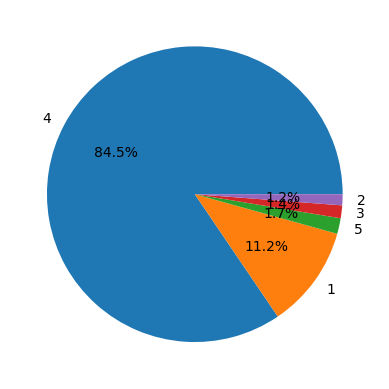

In [ ]:
plt.pie(data['intensidad'].value_counts().values,
        labels = data['intensidad'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

Para hacer todo más sencillo y evitar asociaciones indeseadas, vamos a trabajar solo con minúsculas. Además, quitamos los signos de puntuación de los mensajes

In [ ]:
# Convertimos a minúsculas
data['mensaje'] = data['mensaje'].map(lambda x: x.lower())

# Función para eliminar signos de puntuación
def eliminar_signos(texto):
    return re.sub(f"[{re.escape(string.punctuation)}]", "", texto)

# Aplicamos la función al dataset
data['mensaje'] = data['mensaje'].map(eliminar_signos)
data.head()

,mensaje,intensidad
0,cristina cifuentes podrí­a haber sido la presi...,3
1,habrí­a que reabrir el caso el supremo se dedi...,3
2,me parece un poco exagerado pedir más de tres ...,3
3,parece que todos los delincuentes niegan las e...,3
4,preguntárselo al fracasado media carrera en 6 ...,4


Eliminamos las "stopwords" o palabras vacías. Las stopwords son palabras comunes que, en general, no contienen información relevante para el análisis de texto y suelen ser filtradas antes de procesar los datos. Ejemplos típicos de stopwords en español son: "el", "la", "los", "las", "un", "una", "de", "y", "o", etc.

In [ ]:
# Obtenemos las stopwords en español
stop_words = set(stopwords.words('spanish'))
lemmatizer = WordNetLemmatizer()

# Definimos una función para eliminar stopwords y lematizar
def filtrar_palabras(texto):
    palabras_filtradas = []
    for palabra in texto.split():
        if palabra not in stop_words:
            palabra_lema = lemmatizer.lemmatize(palabra)
            palabras_filtradas.append(palabra_lema)
    return ' '.join(palabras_filtradas)

# Aplicamos la función
data['mensaje'] = data['mensaje'].apply(filtrar_palabras)
data.head()

,mensaje,intensidad
0,cristina cifuentes podrí­a haber sido presiden...,3
1,habrí­a reabrir caso supremo dedica proteger s...,3
2,parece exagerado pedir tres años prisión cifue...,3
3,parece delincuentes niegan evidencias pruebas ...,3
4,preguntárselo fracasado medium carrera 6 meses...,4


Creamos los conjuntos de entrenamiento y de test:

In [ ]:
X = data['mensaje']
y = data['intensidad']

# Dividimos el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertimos a numpy arrays
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values -1
y_test = y_test.values -1

# Creamos datasets de TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

Mostramos un mensaje y su intensidad, simplemente para ver que todo va bien:

In [ ]:
for men, inte in train_dataset.take(1):
  print('mensaje: ', men.numpy())
  print('nivel de odio: ', inte.numpy())

mensaje:  b'tarado abascal dice gran lider tarado trump'
nivel de odio:  3


Mezclamos los datos de forma aleatoria:

In [ ]:
BUFFER_SIZE = 10000
BATCH_SIZE = 64

In [ ]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
for men, inte in train_dataset.take(1):
  print('mensaje: ', men.numpy()[:3])
  print()
  print('nivel de odio: ', inte.numpy()[:3])

mensaje:  [b'q vayan tomar culo ok solo pongan noticias sentados banquillo'
 b'pedazo mierda sra consejera'
 b'extra\xc3\xb1a panfleto paso desaparecer realmente vergonzoso']

nivel de odio:  [3 3 3]


Definimos y configuramos un codificador de texto utilizando la capa TextVectorization

In [ ]:
# Empezamos definiendo el tamaño del vocabulario
tamaño_vocabulario = 1000

# Creamos una capa de vectorización de texto
vectorizador = tf.keras.layers.TextVectorization(
    max_tokens=tamaño_vocabulario
)

# Se extraen solo los textos del conjunto de datos de entrenamiento
def extraer_texto(texto, etiqueta):
    return texto

# Adaptamos el vectorizador al texto del conjunto de datos de entrenamiento
dataset_texto = train_dataset.map(extraer_texto)
vectorizador.adapt(dataset_texto)

In [ ]:
# Obtenemos el vocabulario aprendido por la capa de vectorización
vocabulario = np.array(vectorizador.get_vocabulary())

# Mostramos las primeras 20 palabras del vocabulario
primeras_20_palabras = vocabulario[:20]
primeras_20_palabras

array(['', '[UNK]', 'si', 'mierda', 'puta', 'ser', 'asco', 'gobierno',
       'panfleto', 'q', 'españa', 'paí\xads', 'gente', 'vergüenza',
       'gentuza', 'vaya', 'basura', 'va', 'gilipollas', 'solo'],
      dtype='<U25')

## Objetivo y estrategia

El objetivo es construir y comparar modelos recurrentes capaces de clasificar la intensidad de odio de un mensaje.

Se prueban distintas arquitecturas vistas en la asignatura: RNN clásica, LSTM, LSTM bidireccional, GRU y GRU bidireccional. Para cada familia de modelos se realizan varias configuraciones y se comparan los resultados obtenidos.

El dataset presenta un fuerte desbalanceo entre clases, por lo que el accuracy global debe interpretarse con cautela. Para abordar este problema se utilizan pesos de clase, manteniendo todos los datos disponibles y penalizando más los errores en las clases minoritarias.

In [ ]:
from sklearn.utils import class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, BatchNormalization, Bidirectional, Dropout, GRU
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## **1. RNN clásica, Short-Term Memory o Vanilla RNN**



*Primero comprobamos la longitud media de los textos para ajustar la configuración.*

In [ ]:
data['mensaje_longitud'] = data['mensaje'].apply(len)
average_length = data['mensaje_longitud'].mean()
print(f"Longitud media de los textos {average_length:.2f} caracteres")

Longitud media de los textos 62.86 caracteres


*También debemos comprobar que las etiquetas vayan de 0 a 4 se añadió un -1 a los valores de y.*

In [ ]:
print("Valores únicos en y_train:", np.unique(y_train))
print("Valores únicos en y_test:", np.unique(y_test))

Valores únicos en y_train: [0 1 2 3 4]
Valores únicos en y_test: [0 1 2 3 4]


### 1.1. Modelo 1 de RNN clásica

In [ ]:

#Ahora ya podemos hacer el entrenamiento definiendo el modelo previamente
model_vanilla = tf.keras.Sequential([
    vectorizador,
    tf.keras.layers.Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])
model_vanilla.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

for batch_text, batch_label in train_dataset.take(1):
    model_vanilla(batch_text)
model_vanilla.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_vanilla = model_vanilla.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)
loss, accuracy = model_vanilla.evaluate(test_dataset)
print(f"Precisión en test: {accuracy:.4f}")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (64, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (64, None, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (64, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (64, 64)               │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (64, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,741 (299.77 KB)

 Trainable params: 76,741 (299.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7882 - loss: 0.8979 - val_accuracy: 0.8612 - val_loss: 0.4918
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8622 - loss: 0.4729 - val_accuracy: 0.8709 - val_loss: 0.4505
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8720 - loss: 0.4103 - val_accuracy: 0.8644 - val_loss: 0.4496
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8870 - loss: 0.3317 - val_accuracy: 0.8583 - val_loss: 0.4920
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9134 - loss: 0.2527 - val_accuracy: 0.8493 - val_loss: 0.5629
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9399 - loss: 0.1890 - val_accuracy: 0.8408 - val_loss: 0.6459
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9461 - loss: 0.1598 - val_accuracy: 0.8453 - val_loss: 0.7952
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9566 - loss: 0.1322 - val_ac

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

loss, accuracy = model_vanilla.evaluate(test_dataset)
print(f"Accuracy on test set: {accuracy:.4f}")

y_pred_probs = model_vanilla.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, digits=3))

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8612 - loss: 0.4620
Accuracy on test set: 0.8644
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0      0.611     0.289     0.392       277
           1      0.000     0.000     0.000        25
           2      0.000     0.000     0.000        32
           3      0.879     0.982     0.927      2081
           4      0.000     0.000     0.000        41

    accuracy                          0.864      2456
   macro avg      0.298     0.254     0.264      2456
weighted avg      0.813     0.864     0.830      2456



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


*Se aprecia que el modelo aprende muy rápido y tiende a sobreajustarse de las primeras epochs. Para controlar esto, se probará añadiendo dropout y batch normalization.*

*Por otro lado también se aprecia claramente que la única clase que detecta bien es la clase mayoritaria y como el desbalanceo es tanto, el accuracy general del modelo sigue siendo alto.*

### 1.2. Modelo 2 RNN clásica

*Con respecto al modelo anterior, se ha decidido añadir dropout para evitar overfitting y una segunda capa densa. Añadir más de una SimpleRNN no es común, pues no escala bien a muchas capas, aspecto que sí se contempla en LSTM o GRU).*

*También se añaden los pesos de la clase para ver si afecta al classification report.*

In [ ]:

pesos_clase = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
pesos_clase = dict(enumerate(pesos_clase))

model_vanilla_2 = tf.keras.Sequential([
    vectorizador,
    tf.keras.layers.Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    tf.keras.layers.SimpleRNN(64),
    Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

model_vanilla_2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

for batch_text, batch_label in train_dataset.take(1):
    model_vanilla_2(batch_text)
model_vanilla_2.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_vanilla_2 = model_vanilla_2.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    class_weight=pesos_clase,
    callbacks=[early_stopping]
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (64, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (64, None, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (64, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (64, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (64, 128)              │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (64, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (64, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,157 (348.27 KB)

 Trainable params: 89,157 (348.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.4699 - loss: 1.5389 - val_accuracy: 0.6010 - val_loss: 1.3104
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5752 - loss: 1.4494 - val_accuracy: 0.4511 - val_loss: 1.4433
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6011 - loss: 1.0519 - val_accuracy: 0.5525 - val_loss: 1.1661
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6582 - loss: 0.7844 - val_accuracy: 0.6136 - val_loss: 0.9694
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.7211 - loss: 0.4781 - val_accuracy: 0.6539 - val_loss: 0.9260
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7450 - loss: 0.3694 - val_accuracy: 0.6824 - val_loss: 0.8246
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.7776 - loss: 0.2784 - val_accuracy: 0.5977 - val_loss: 1.0936
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7713 - loss: 0.3258 - val_ac

In [ ]:
loss, accuracy = model_vanilla_2.evaluate(test_dataset)
print(f"Accuracy on test set: {accuracy:.4f}")

y_pred_probs = model_vanilla_2.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, digits=3))

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7246 - loss: 0.8289
Accuracy on test set: 0.7292
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0      0.344     0.523     0.415       277
           1      0.079     0.320     0.127        25
           2      0.045     0.094     0.061        32
           3      0.936     0.781     0.851      2081
           4      0.077     0.244     0.117        41

    accuracy                          0.729      2456
   macro avg      0.296     0.392     0.314      2456
weighted avg      0.834     0.729     0.772      2456



*Se aprecia una mejora en aquellas clases que antes tenían 0 en F1-Score (1,2 y 4). Sin embargo, han empeorado las otras clases. Por lo que habrá que tomar una decisión para ver qué es mejor.*

*En cuanto al entrenamiento, vemos como estos cambios han influido en la velocidad del entrenamiento y en general en todas las métricas, pues se han obtenido peores resultados, claramente debido a los pesos introducidos.*

*Para este caso, como mejora lo anterior, se decide visualizar las curvas de aprendizaje de entrenamiento y test.*

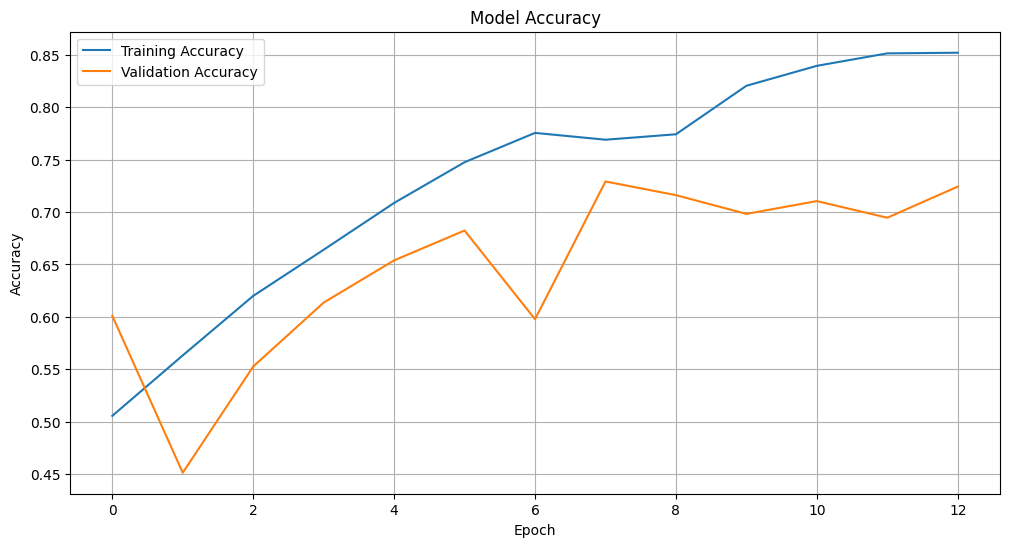

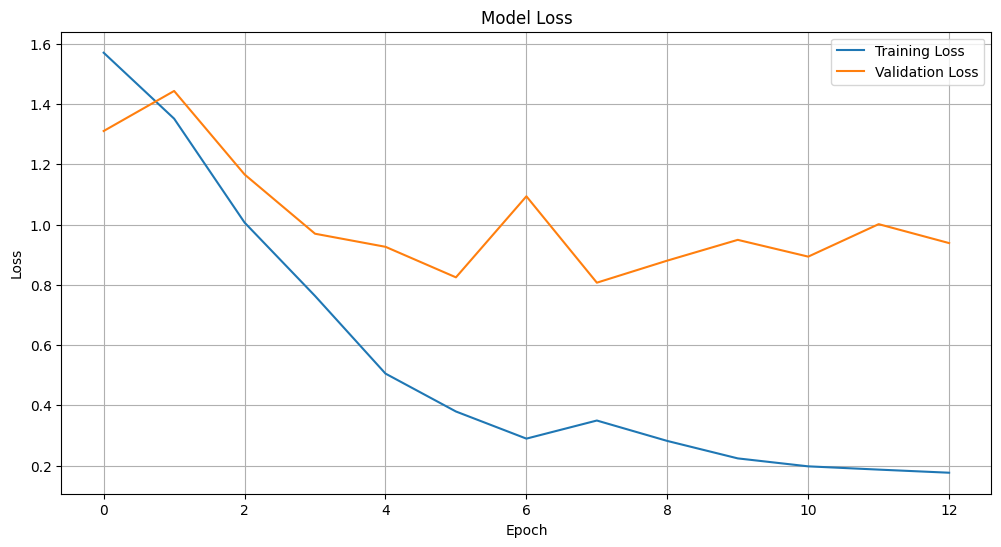

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history_vanilla_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_vanilla_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.figure(figsize=(12, 6))
plt.plot(history_vanilla_2.history['loss'], label='Training Loss')
plt.plot(history_vanilla_2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### 1.3. Modelo 3 RNN clásica

En este caso se comprueba si modificar el tamaño de la capa SimpleRNN y del embedding tiene algún efecto sobre el rendimiento del modelo.

In [ ]:
model_vanilla_3 = tf.keras.Sequential([
    vectorizador,
    tf.keras.layers.Embedding(input_dim=tamaño_vocabulario, output_dim=128, mask_zero=True),
    tf.keras.layers.SimpleRNN(128),
    Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

model_vanilla_3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

for batch_text, batch_label in train_dataset.take(1):
    model_vanilla_3(batch_text)
model_vanilla_3.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_vanilla_3 = model_vanilla_3.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    class_weight=pesos_clase,
    callbacks=[early_stopping]
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (64, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_9 (Embedding)         │ (64, None, 128)        │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (64, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (64, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (64, 128)              │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (64, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (64, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,989 (726.52 KB)

 Trainable params: 185,989 (726.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.1675 - loss: 1.6296 - val_accuracy: 0.3384 - val_loss: 1.6383
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.4396 - loss: 1.4580 - val_accuracy: 0.3864 - val_loss: 1.4405
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.5274 - loss: 1.2092 - val_accuracy: 0.5171 - val_loss: 1.1833
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.5835 - loss: 1.0919 - val_accuracy: 0.5794 - val_loss: 1.2162
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6310 - loss: 0.8542 - val_accuracy: 0.5851 - val_loss: 1.0014
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6129 - loss: 0.8815 - val_accuracy: 0.6397 - val_loss: 0.8232
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.7264 - loss: 0.4826 - val_accuracy: 0.5965 - val_loss: 1.0652
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7252 - loss: 0.4238 - val

In [ ]:
loss, accuracy = model_vanilla_3.evaluate(test_dataset)
print(f"Accuracy on test set: {accuracy:.4f}")

y_pred_probs = model_vanilla_3.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, digits=3))

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7133 - loss: 0.7734
Accuracy on test set: 0.7142
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0      0.318     0.570     0.408       277
           1      0.050     0.200     0.079        25
           2      0.010     0.031     0.015        32
           3      0.942     0.761     0.842      2081
           4      0.090     0.171     0.118        41

    accuracy                          0.714      2456
   macro avg      0.282     0.347     0.292      2456
weighted avg      0.836     0.714     0.762      2456



No ha supuesto mejora, incluso ha empeorado los resultados anteriores.

## **2. LSTM**

Después de trabajar con redes neuronales recurrentes (RNN), construimos dos modelos basados en LSTM (Long Short-Term Memory), una variante que mejora significativamente la capacidad de la red para capturar y mantener el contexto a lo largo de secuencias más largas.

### 2.1. Modelo 1 LSTM (una sola capa LSTM)

In [ ]:
model_lstm = tf.keras.Sequential([
    vectorizador,  # Ya transforma texto en secuencias
    Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Inicializa el modelo para ver el resumen
for batch_text, batch_label in train_dataset.take(1):
    model_lstm(batch_text)

model_lstm.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Entrenamiento
history_lstm = model_lstm.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

# Evaluación
loss, accuracy = model_lstm.evaluate(test_dataset)
print(f"Precisión en test (LSTM): {accuracy:.4f}")


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (64, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_10 (Embedding)        │ (64, None, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (64, 64)               │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (64, 64)               │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (64, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,509 (396.52 KB)

 Trainable params: 101,509 (396.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.8388 - loss: 0.9411 - val_accuracy: 0.8473 - val_loss: 0.5246
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8496 - loss: 0.5133 - val_accuracy: 0.8636 - val_loss: 0.4352
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8648 - loss: 0.4285 - val_accuracy: 0.8689 - val_loss: 0.4306
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8767 - loss: 0.3894 - val_accuracy: 0.8571 - val_loss: 0.4329
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.8780 - loss: 0.3788 - val_accuracy: 0.8677 - val_loss: 0.4276
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8898 - loss: 0.3462 - val_accuracy: 0.8526 - val_loss: 0.4429
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8926 - loss: 0.3220 - val_accuracy: 0.8579 - val_loss: 0.4579
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8904 - loss: 0.3176 - v

### 2.2. Modelo 2 LSTM (dos capas LSTM)

In [ ]:
model_lstm_stacked = tf.keras.Sequential([
    vectorizador,
    Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    LSTM(64, return_sequences=True),    # Primera capa LSTM, devuelve secuencia completa
    Dropout(0.3),
    LSTM(32),                           # Segunda capa LSTM, procesa la secuencia
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_lstm_stacked.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Inicializa el modelo para ver el resumen
for batch_text, batch_label in train_dataset.take(1):
    model_lstm_stacked(batch_text)

model_lstm_stacked.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_lstm_stacked = model_lstm_stacked.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

loss, accuracy = model_lstm_stacked.evaluate(test_dataset)
print(f"Precisión en test (LSTM apilado): {accuracy:.4f}")


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (64, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_11 (Embedding)        │ (64, None, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (64, None, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (64, None, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (64, 32)               │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (64, 32)               │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (64, 64)               │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (64, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,005 (437.52 KB)

 Trainable params: 111,941 (437.27 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - accuracy: 0.8292 - loss: 0.7344 - val_accuracy: 0.8477 - val_loss: 0.8236
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.8613 - loss: 0.4566 - val_accuracy: 0.8477 - val_loss: 0.5643
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.8763 - loss: 0.3931 - val_accuracy: 0.8603 - val_loss: 0.5100
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.8752 - loss: 0.3654 - val_accuracy: 0.8624 - val_loss: 0.4497
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.8891 - loss: 0.3176 - val_accuracy: 0.8628 - val_loss: 0.4895
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.8943 - loss: 0.2992 - val_accuracy: 0.8290 - val_loss: 0.5057
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.9061 - loss: 0.2750 - val_accuracy: 0.8522 - val_loss: 0.5230
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.9178 - loss: 0

### 2.3. Modelo 3 LSTM bidireccional (con una capa bidireccional)

Después de entrenar un modelo LSTM unidireccional, implementamos una arquitectura LSTM bidireccional para mejorar la comprensión contextual de los mensajes. Esta variante procesa el texto tanto en orden directo como inverso, permitiendo al modelo acceder al contexto pasado y futuro de cada palabra.

In [ ]:
# Modelo LSTM Bidireccional
model_bilstm = Sequential([
    vectorizador,  # Capa TextVectorization definida previamente
    Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')  # Para clasificación multiclase
])

model_bilstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Inicializa el modelo con un batch para construirlo
for batch_text, batch_label in train_dataset.take(1):
    model_bilstm(batch_text)

model_bilstm.summary()

# Callback de parada temprana
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Entrenamiento
history_bilstm = model_bilstm.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

# Evaluación
loss, accuracy = model_bilstm.evaluate(test_dataset)
print(f"Precisión en test (Bidirectional LSTM): {accuracy:.4f}")


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (64, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (64, None, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (64, 128)              │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (64, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (64, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,629 (541.52 KB)

 Trainable params: 138,629 (541.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.8176 - loss: 0.9253 - val_accuracy: 0.8587 - val_loss: 0.4809
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.8570 - loss: 0.4590 - val_accuracy: 0.8726 - val_loss: 0.4457
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.8772 - loss: 0.4011 - val_accuracy: 0.8652 - val_loss: 0.4304
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.8832 - loss: 0.3546 - val_accuracy: 0.8717 - val_loss: 0.4246
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.8892 - loss: 0.3310 - val_accuracy: 0.8746 - val_loss: 0.4388
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - accuracy: 0.8905 - loss: 0.3180 - val_accuracy: 0.8677 - val_loss: 0.4634
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.9021 - loss: 0.2707 - val_accuracy: 0.8485 - val_loss: 0.4847
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.9168 - loss: 0

### 2.4. Modelo 4 LSTM bidireccional (con dos capas bidireccionales)

In [ ]:
model_bilstm_stacked = Sequential([
    vectorizador,
    Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_bilstm_stacked.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

for batch_text, batch_label in train_dataset.take(1):
    model_bilstm_stacked(batch_text)

model_bilstm_stacked.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model_bilstm_stacked.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

loss, accuracy = model_bilstm_stacked.evaluate(test_dataset)
print(f"Precisión en test (Bidirectional LSTM apilado): {accuracy:.4f}")


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (64, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_13 (Embedding)        │ (64, None, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (64, None, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (64, None, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (64, 64)               │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (64, 64)               │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (64, 64)               │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (64, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,005 (687.52 KB)

 Trainable params: 175,877 (687.02 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 44s 217ms/step - accuracy: 0.7980 - loss: 0.7424 - val_accuracy: 0.8477 - val_loss: 0.9285
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 34s 221ms/step - accuracy: 0.8699 - loss: 0.4226 - val_accuracy: 0.8481 - val_loss: 0.6636
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 229ms/step - accuracy: 0.8799 - loss: 0.3648 - val_accuracy: 0.8616 - val_loss: 0.4856
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 40s 222ms/step - accuracy: 0.8941 - loss: 0.3166 - val_accuracy: 0.8652 - val_loss: 0.4487
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 233ms/step - accuracy: 0.9089 - loss: 0.2596 - val_accuracy: 0.8327 - val_loss: 0.5245
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 40s 224ms/step - accuracy: 0.9244 - loss: 0.2237 - val_accuracy: 0.8559 - val_loss: 0.5915
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 214ms/step - accuracy: 0.9312 - loss: 0.1918 - val_accuracy: 0.8498 - val_loss: 0.6722
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 34s 222ms/step - accuracy: 0.9472 - loss: 0

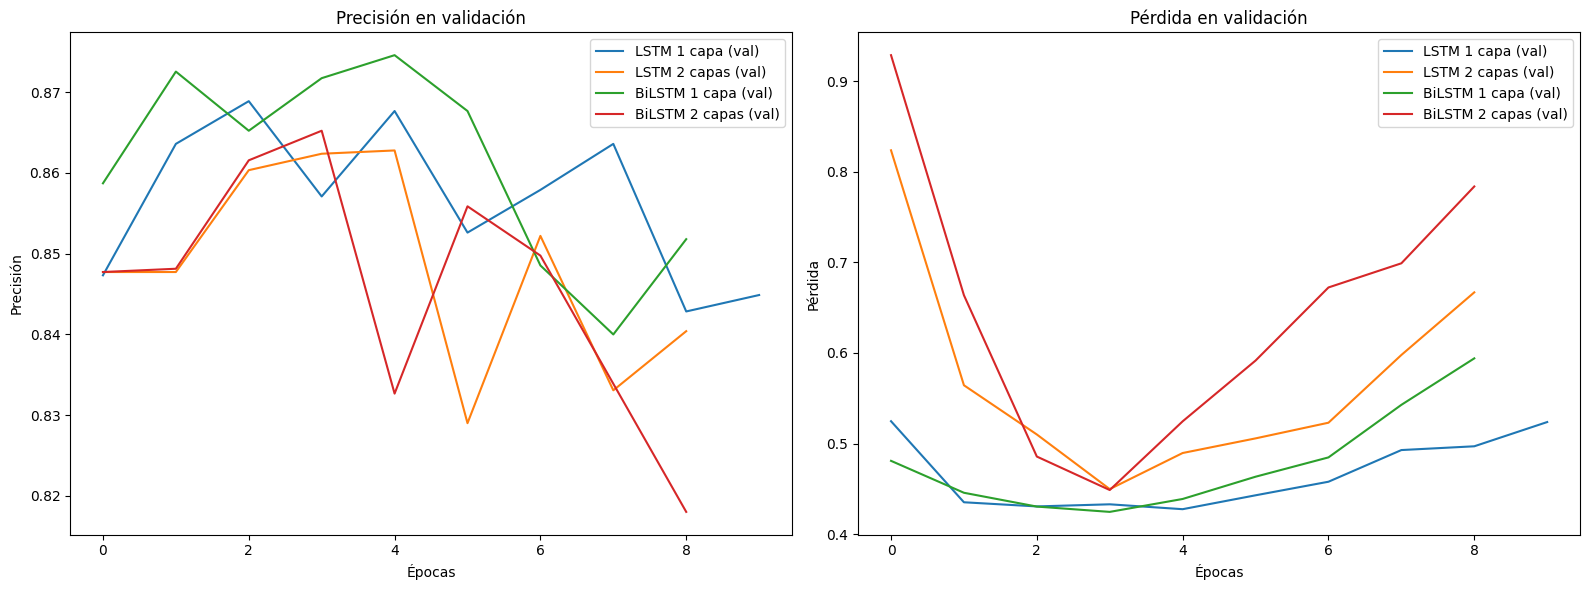

In [ ]:
def plot_multiple_histories(histories, nombres_modelos):
    plt.figure(figsize=(16, 6))

    # Gráfico de Precisión
    plt.subplot(1, 2, 1)
    for hist, nombre in zip(histories, nombres_modelos):
        plt.plot(hist.history['val_accuracy'], label=f'{nombre} (val)')
    plt.title('Precisión en validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    # Gráfico de Pérdida
    plt.subplot(1, 2, 2)
    for hist, nombre in zip(histories, nombres_modelos):
        plt.plot(hist.history['val_loss'], label=f'{nombre} (val)')
    plt.title('Pérdida en validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Ejecutar con los 4 modelos
plot_multiple_histories(
    histories=[history_lstm, history_lstm_stacked, history_bilstm, history],
    nombres_modelos=["LSTM 1 capa", "LSTM 2 capas", "BiLSTM 1 capa", "BiLSTM 2 capas"]
)

## **3. GRU**

# GRU SIMPLE (una capa)

In [ ]:
model_gru_simple = Sequential([
    vectorizador,
    Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    GRU(64),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_gru_simple.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

for batch_text, batch_label in train_dataset.take(1):
    model_gru_simple(batch_text)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_gru_simple = model_gru_simple.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

loss, accuracy = model_gru_simple.evaluate(test_dataset)
print(f"Precisión en test (GRU simple): {accuracy:.4f}")

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.8152 - loss: 0.9409 - val_accuracy: 0.8583 - val_loss: 0.4868
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8613 - loss: 0.4640 - val_accuracy: 0.8689 - val_loss: 0.4362
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.8767 - loss: 0.4003 - val_accuracy: 0.8705 - val_loss: 0.4393
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.8788 - loss: 0.3754 - val_accuracy: 0.8664 - val_loss: 0.4424
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.8902 - loss: 0.3264 - val_accuracy: 0.8616 - val_loss: 0.4542
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.8912 - loss: 0.3192 - val_accuracy: 0.8616 - val_loss: 0.4666
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.8980 - loss: 0.2884 - val_accuracy: 0.8534 - val_loss: 0.4992
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8624 - loss: 0.4507
Precisión en t

# GRU APILADA (stacked GRU)

In [ ]:

model_gru_stacked = Sequential([
    vectorizador,
    Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    GRU(64, return_sequences=True),
    Dropout(0.3),
    GRU(32),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_gru_stacked.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

for batch_text, batch_label in train_dataset.take(1):
    model_gru_stacked(batch_text)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_gru_stacked = model_gru_stacked.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

loss, accuracy = model_gru_stacked.evaluate(test_dataset)
print(f"Precisión en test (GRU apilada): {accuracy:.4f}")

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 26s 127ms/step - accuracy: 0.6949 - loss: 0.9209 - val_accuracy: 0.8477 - val_loss: 0.7036
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.8627 - loss: 0.4402 - val_accuracy: 0.8477 - val_loss: 0.5335
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.8740 - loss: 0.3829 - val_accuracy: 0.8640 - val_loss: 0.4385
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.8777 - loss: 0.3541 - val_accuracy: 0.8664 - val_loss: 0.4717
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.8913 - loss: 0.3165 - val_accuracy: 0.8546 - val_loss: 0.4811
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - accuracy: 0.9008 - loss: 0.2861 - val_accuracy: 0.8445 - val_loss: 0.5273
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 116ms/step - accuracy: 0.9064 - loss: 0.2597 - val_accuracy: 0.8599 - val_loss: 0.6758
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.9188 - loss: 0

# BI-GRU (Bidireccional GRU)

In [ ]:
model_bigru = Sequential([
    vectorizador,
    Embedding(input_dim=tamaño_vocabulario, output_dim=64, mask_zero=True),
    Bidirectional(GRU(64)),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_bigru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

for batch_text, batch_label in train_dataset.take(1):
    model_bigru(batch_text)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_bigru = model_bigru.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

loss, accuracy = model_bigru.evaluate(test_dataset)
print(f"Precisión en test (BiGRU): {accuracy:.4f}")

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - accuracy: 0.8365 - loss: 0.8814 - val_accuracy: 0.8652 - val_loss: 0.4605
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.8684 - loss: 0.4366 - val_accuracy: 0.8730 - val_loss: 0.4245
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.8781 - loss: 0.3763 - val_accuracy: 0.8734 - val_loss: 0.4309
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.8875 - loss: 0.3445 - val_accuracy: 0.8726 - val_loss: 0.4486
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - accuracy: 0.8938 - loss: 0.3140 - val_accuracy: 0.8636 - val_loss: 0.4673
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.9065 - loss: 0.2723 - val_accuracy: 0.8514 - val_loss: 0.5400
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - accuracy: 0.9191 - loss: 0.2398 - val_accuracy: 0.8542 - val_loss: 0.5936
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8646 - loss: 0.4462
Precisión

# Comparativa gráfica de los 3 modelos GRU

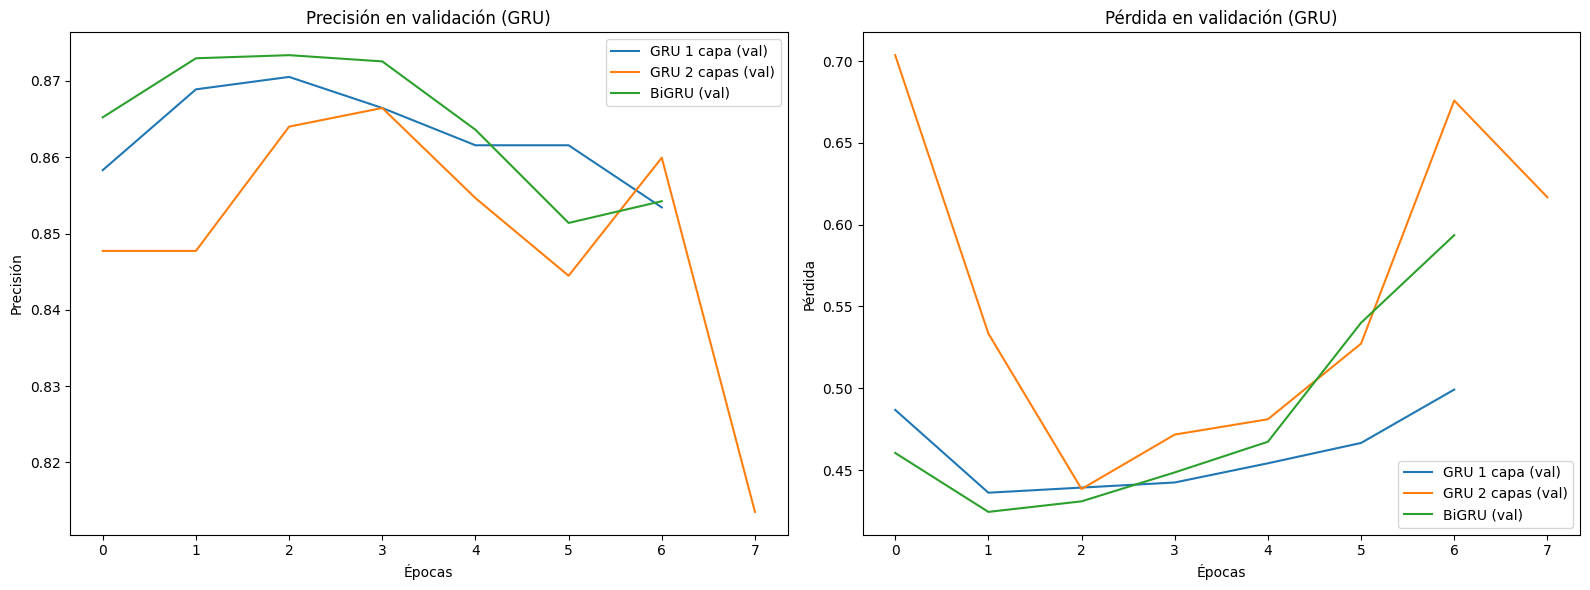

In [ ]:
def plot_gru_histories(histories, nombres_modelos):
    plt.figure(figsize=(16, 6))

    # Precisión
    plt.subplot(1, 2, 1)
    for hist, nombre in zip(histories, nombres_modelos):
        plt.plot(hist.history['val_accuracy'], label=f'{nombre} (val)')
    plt.title('Precisión en validación (GRU)')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    # Pérdida
    plt.subplot(1, 2, 2)
    for hist, nombre in zip(histories, nombres_modelos):
        plt.plot(hist.history['val_loss'], label=f'{nombre} (val)')
    plt.title('Pérdida en validación (GRU)')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Llamada al gráfico
plot_gru_histories(
    histories=[history_gru_simple, history_gru_stacked, history_bigru],
    nombres_modelos=["GRU 1 capa", "GRU 2 capas", "BiGRU"]
)

## **4. Conclusiones**

# Primero comparamos todos los modelos

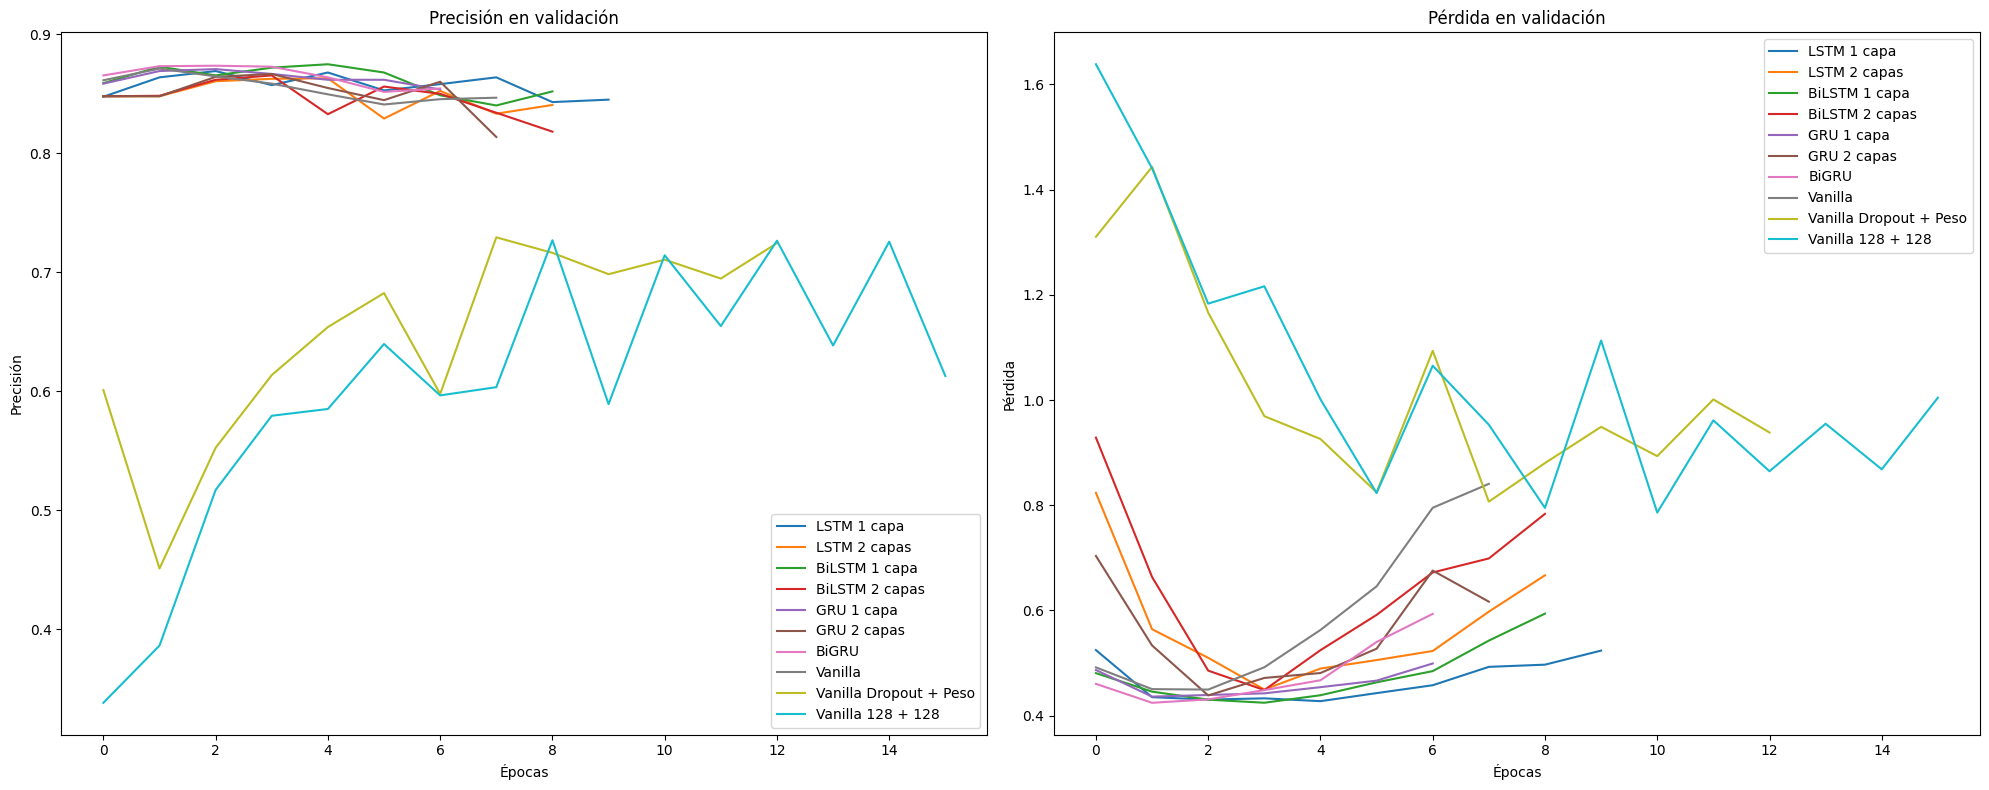

In [ ]:
def plot_all_10_histories(histories, nombres_modelos):
    plt.figure(figsize=(20, 8))

    # Gráfico de Precisión
    plt.subplot(1, 2, 1)
    for hist, nombre in zip(histories, nombres_modelos):
        plt.plot(hist.history['val_accuracy'], label=f'{nombre}')
    plt.title('Precisión en validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend(loc='lower right')

    # Gráfico de Pérdida
    plt.subplot(1, 2, 2)
    for hist, nombre in zip(histories, nombres_modelos):
        plt.plot(hist.history['val_loss'], label=f'{nombre}')
    plt.title('Pérdida en validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Llamada al gráfico con los 10 modelos
plot_all_10_histories(
    histories=[
        history_lstm,
        history_lstm_stacked,
        history_bilstm,
        history,
        history_gru_simple,
        history_gru_stacked,
        history_bigru,
        history_vanilla,
        history_vanilla_2,
        history_vanilla_3
    ],
    nombres_modelos=[
        "LSTM 1 capa",
        "LSTM 2 capas",
        "BiLSTM 1 capa",
        "BiLSTM 2 capas",
        "GRU 1 capa",
        "GRU 2 capas",
        "BiGRU",
        "Vanilla",
        "Vanilla Dropout + Peso",
        "Vanilla 128 + 128"
    ]
)

In [ ]:
# Lista de modelos y sus histories + evaluaciones
modelos_info = [
    ("LSTM 1 capa", history_lstm, model_lstm),
    ("LSTM 2 capas", history_lstm_stacked, model_lstm_stacked),
    ("BiLSTM 1 capa", history_bilstm, model_bilstm),
    ("BiLSTM 2 capas", history, model_bilstm_stacked),
    ("GRU 1 capa", history_gru_simple, model_gru_simple),
    ("GRU 2 capas", history_gru_stacked, model_gru_stacked),
    ("BiGRU", history_bigru, model_bigru),
    ("Vanilla", history_vanilla, model_vanilla),
    ("Vanilla Dropout + Peso", history_vanilla_2, model_vanilla_2),
    ("Vanilla 128 + 128", history_vanilla_3, model_vanilla_3)
]

# Crear resumen
resumen = []
for nombre, hist, modelo in modelos_info:
    acc_train_max = max(hist.history.get('accuracy', [0]))
    acc_val_max = max(hist.history.get('val_accuracy', [0]))

    # Evaluación en test
    loss_test, acc_test = modelo.evaluate(test_dataset, verbose=0)

    resumen.append({
        "Modelo": nombre,
        "Mejor precisión (train)": round(acc_train_max, 4),
        "Mejor precisión (val)": round(acc_val_max, 4),
        "Precisión en test": round(acc_test, 4)
    })

# Mostrar como DataFrame
df_metricas_modelos = pd.DataFrame(resumen).sort_values("Mejor precisión (val)", ascending=False)

# Mostrar tabla
print(df_metricas_modelos)

                   Modelo  Mejor precisión (train)  Mejor precisión (val)  \
2           BiLSTM 1 capa                   0.9204                 0.8746   
6                   BiGRU                   0.9130                 0.8734   
7                 Vanilla                   0.9557                 0.8709   
4              GRU 1 capa                   0.8942                 0.8705   
0             LSTM 1 capa                   0.9017                 0.8689   
5             GRU 2 capas                   0.9133                 0.8664   
3          BiLSTM 2 capas                   0.9486                 0.8652   
1            LSTM 2 capas                   0.9220                 0.8628   
8  Vanilla Dropout + Peso                   0.8522                 0.7292   
9       Vanilla 128 + 128                   0.8216                 0.7268   

   Precisión en test  
2             0.8717  
6             0.8730  
7             0.8644  
4             0.8689  
0             0.8677  
5             

## Conclusión final

Se han comparado distintas arquitecturas recurrentes para la clasificación multiclase de intensidad de odio en mensajes de texto.

Los resultados muestran que los modelos recurrentes bidireccionales, especialmente BiLSTM y BiGRU, ofrecen el mejor rendimiento global en validación y test. Procesar la secuencia en ambos sentidos permite capturar mejor el contexto del mensaje.

También se observa que el fuerte desbalanceo de clases condiciona el comportamiento de los modelos. Aunque el accuracy global puede ser elevado, este valor debe interpretarse junto con métricas por clase, ya que las clases mayoritarias dominan la distribución del dataset.

En conjunto, los modelos BiLSTM y BiGRU ofrecen el mejor compromiso entre capacidad de generalización y rendimiento en test para esta tarea.